# Pooya Valizadeh
### CarPrice_Assignment dataset

www.github.com/pooyavalizadeh

In [208]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras

In [209]:
df = pd.read_csv("CarPrice_Assignment.csv")

In [210]:
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


## preprocessing

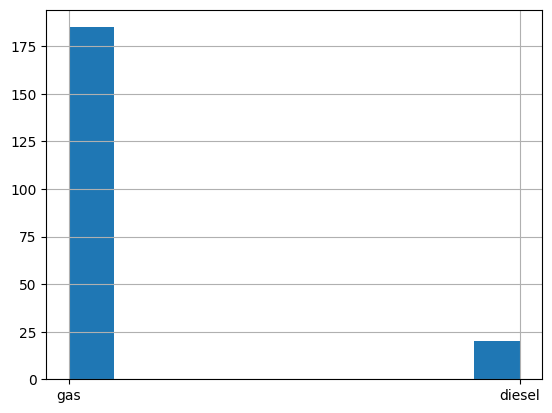

In [211]:
df["fueltype"].hist()
plt.show()

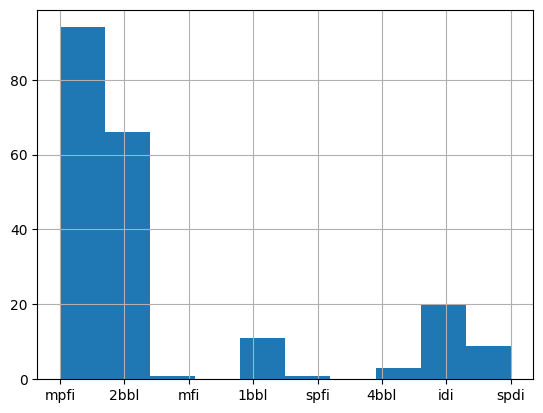

In [212]:
df["fuelsystem"].hist()
plt.show()

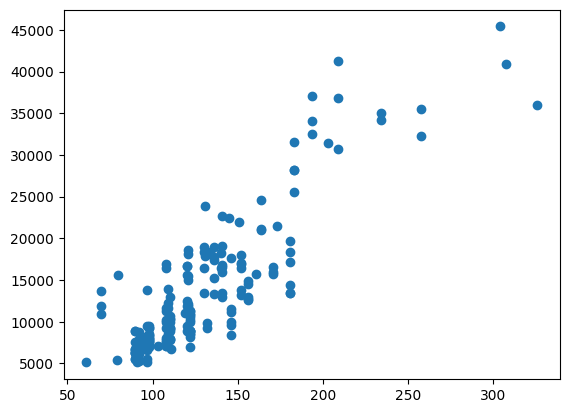

In [213]:
plt.scatter(df["enginesize"],df["price"])
plt.show()

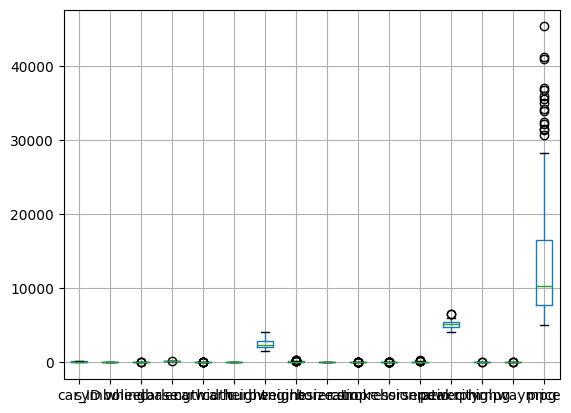

In [214]:
df.boxplot()
plt.show()

In [215]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [216]:
df.dtypes

,0
car_ID,int64
symboling,int64
CarName,object
fueltype,object
aspiration,object
doornumber,object
carbody,object
drivewheel,object
enginelocation,object
wheelbase,float64


In [217]:
df["fueltype"] = df["fueltype"].map({"diesel" : 1, "gas" : 0})
from keras.utils import to_categorical
df["fueltype"] = to_categorical(df["fueltype"])

In [218]:
df["cylindernumber"].value_counts()

,count
cylindernumber,
four,159
six,24
five,11
eight,5
two,4
twelve,1
three,1


In [219]:
df["cylindernumber"] = df["cylindernumber"].map({"four" : 0, "six" : 1,
"five":2,"eight":3,"two":4,"three":5,"twelve":6})
df["cylindernumber"] = to_categorical(df["cylindernumber"])

In [220]:
df["doornumber"] = df["doornumber"].map({"four" : 1, "two" : 0})
df["doornumber"] = to_categorical(df["doornumber"])

In [221]:
df["enginetype"].value_counts()

,count
enginetype,
ohc,148
ohcf,15
ohcv,13
dohc,12
l,12
rotor,4
dohcv,1


In [222]:
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,1.0,std,1.0,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,1.0,std,1.0,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,1.0,std,1.0,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,1.0,std,0.0,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,1.0,std,0.0,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),1.0,std,0.0,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,1.0,turbo,0.0,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,1.0,std,0.0,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,0.0,turbo,0.0,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [223]:
df = df.drop(columns=["car_ID","symboling","CarName","aspiration","carbody","drivewheel","enginelocation",
"enginetype","fuelsystem"])

In [224]:
df.dtypes

,0
fueltype,float64
doornumber,float64
wheelbase,float64
carlength,float64
carwidth,float64
carheight,float64
curbweight,int64
cylindernumber,float64
enginesize,int64
boreratio,float64


In [225]:
df.describe()

,fueltype,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.902439,0.439024,98.756585,174.049268,65.907805,53.724878,2555.565854,0.775610,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,0.297446,0.497483,6.021776,12.337289,2.145204,2.443522,520.680204,0.418201,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,0.000000,0.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,0.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,1.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,1.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,0.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,1.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,1.000000,1.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,1.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,1.000000,1.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,1.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [226]:
x = df.drop(columns="price").values
y = df["price"].values

In [227]:
from sklearn.model_selection import train_test_split as tts
xtrain_ , xtest , ytrain_ , ytest = tts(x,y,test_size=0.15,random_state=26)
xtrain , xval , ytrain , yval = tts(xtrain_,ytrain_,random_state=26,test_size=0.18)

In [228]:
xtrain.shape , ytrain.shape , xtest.shape , ytest.shape , xval.shape , yval.shape

((142, 16), (142,), (31, 16), (31,), (32, 16), (32,))

In [229]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
scale1 = StandardScaler()

xtrain = scale.fit_transform(xtrain)
xtest = scale.transform(xtest)
xval = scale.transform(xval)

ytrain = scale1.fit_transform(ytrain.reshape(-1, 1))
ytest = scale1.transform(ytest.reshape(-1, 1))
yval = scale1.transform(yval.reshape(-1, 1))

## builing first model

In [230]:
xtrain.shape

(142, 16)

In [231]:
input_ = keras.layers.Input(shape = (16,))
layer1 = keras.layers.Dense(70 , activation="relu",kernel_initializer=keras.initializers.he_normal())(input_)
normalize1 = keras.layers.BatchNormalization()(layer1)
layer2 = keras.layers.Dense(50,activation="relu",kernel_initializer=keras.initializers.he_normal())(normalize1)
normalize2 = keras.layers.BatchNormalization()(layer2)
layer2_5 = keras.layers.Dense(50,activation="relu",kernel_initializer=keras.initializers.he_normal())(normalize2)
normalize3 = keras.layers.BatchNormalization()(layer2_5)
layer3 = keras.layers.Dense(10,activation="relu",kernel_initializer=keras.initializers.he_normal())(normalize3)
normalize4 = keras.layers.BatchNormalization()(layer3)
output = keras.layers.Dense(1)(normalize4)
model = keras.Model(input_,output)

In [232]:
model.summary()

Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_36 (InputLayer)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_132 (Dense)               │ (None, 70)             │         1,190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 70)             │           280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_133 (Dense)               │ (None, 50)             │         3,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_134 (Dense)               │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_135 (Dense)               │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_136 (Dense)               │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,531 (33.32 KB)

 Trainable params: 8,171 (31.92 KB)

 Non-trainable params: 360 (1.41 KB)

In [233]:
model.compile(loss = keras.losses.MeanAbsoluteError(), optimizer= keras.optimizers.Adam(),
metrics= [keras.metrics.MeanAbsoluteError(),keras.metrics.RootMeanSquaredError()])

In [234]:
history = model.fit(xtrain , ytrain , validation_data=(xval,yval),epochs=100,
batch_size=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 382ms/step - loss: 1.1492 - mean_absolute_error: 1.1492 - root_mean_squared_error: 1.4813 - val_loss: 0.9077 - val_mean_absolute_error: 0.9077 - val_root_mean_squared_error: 1.0958
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.9719 - mean_absolute_error: 0.9719 - root_mean_squared_error: 1.2504 - val_loss: 0.8492 - val_mean_absolute_error: 0.8492 - val_root_mean_squared_error: 1.0098
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.7163 - mean_absolute_error: 0.7163 - root_mean_squared_error: 0.9762 - val_loss: 0.8124 - val_mean_absolute_error: 0.8124 - val_root_mean_squared_error: 0.9637
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.6248 - mean_absolute_error: 0.6248 - root_mean_squared_error: 0.8474 - val_loss: 0.8040 - val_mean_absolute_error: 0.8040 - val_root_mean_squared_error: 0.9457
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.5862 - mean_absolute_error: 0.5862 - root_mean_squared_err

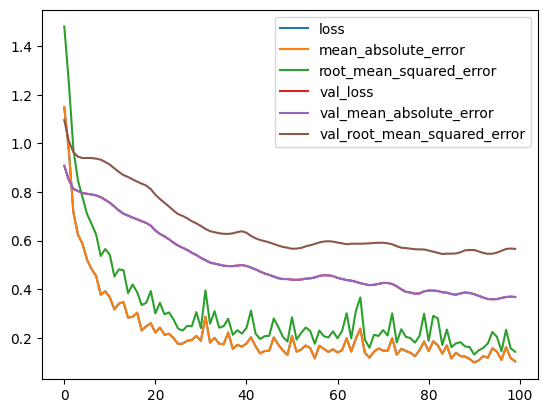

In [235]:
pd.DataFrame(history.history).plot()
plt.show()

In [236]:
model.evaluate(xtest,ytest)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.4239 - mean_absolute_error: 0.4239 - root_mean_squared_error: 0.5556


[0.4239231050014496, 0.4239231050014496, 0.5555860996246338]

## builing 2 to 5 models

In [237]:
input_ = keras.layers.Input(shape = (16,))
layer1 = keras.layers.Dense(85 , activation="relu",kernel_initializer=keras.initializers.he_normal())(input_)
output = keras.layers.Dense(1)(layer1)
model1 = keras.Model(input_,output)
model1.compile(loss = keras.losses.MeanAbsoluteError(),optimizer="Adam",metrics=["mae"])
history1 = model1.fit(xtrain , ytrain , validation_data=(xval,yval),epochs=100,
batch_size=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 343ms/step - loss: 1.2331 - mae: 1.2331 - val_loss: 1.1443 - val_mae: 1.1443
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 1.1220 - mae: 1.1220 - val_loss: 1.0482 - val_mae: 1.0482
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 1.0194 - mae: 1.0194 - val_loss: 0.9577 - val_mae: 0.9577
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.9263 - mae: 0.9263 - val_loss: 0.8789 - val_mae: 0.8789
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.8346 - mae: 0.8346 - val_loss: 0.8120 - val_mae: 0.8120
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.7648 - mae: 0.7648 - val_loss: 0.7500 - val_mae: 0.7500
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 0.7010 - mae: 0.7010 - val_loss: 0.7077 - val_mae: 0.7077
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.6416 - mae: 0.6416 - val_loss: 0.6684 - val_mae: 0.6684
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.5838

In [238]:
input_ = keras.layers.Input(shape = (16,))
layer1 = keras.layers.Dense(200 , activation="relu",kernel_initializer=keras.initializers.he_normal())(input_)
output = keras.layers.Dense(1)(layer1)
model1 = keras.Model(input_,output)
model1.compile(loss = keras.losses.MeanAbsoluteError(),optimizer="Adam",metrics=["mae"])
history2 = model1.fit(xtrain , ytrain , validation_data=(xval,yval),epochs=100,
batch_size=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 376ms/step - loss: 0.6738 - mae: 0.6738 - val_loss: 0.7953 - val_mae: 0.7953
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.5591 - mae: 0.5591 - val_loss: 0.7259 - val_mae: 0.7259
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 0.5024 - mae: 0.5024 - val_loss: 0.6509 - val_mae: 0.6509
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.4730 - mae: 0.4730 - val_loss: 0.5802 - val_mae: 0.5802
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.4363 - mae: 0.4363 - val_loss: 0.5307 - val_mae: 0.5307
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.4000 - mae: 0.4000 - val_loss: 0.5087 - val_mae: 0.5087
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.3818 - mae: 0.3818 - val_loss: 0.4895 - val_mae: 0.4895
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.3730 - mae: 0.3730 - val_loss: 0.4722 - val_mae: 0.4722
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.3626 - m

In [239]:
input_ = keras.layers.Input(shape = (16,))
layer1 = keras.layers.Dense(300 , activation="relu",kernel_initializer=keras.initializers.he_normal())(input_)
output = keras.layers.Dense(1)(layer1)
model1 = keras.Model(input_,output)
model1.compile(loss = keras.losses.MeanAbsoluteError(),optimizer="Adam",metrics=["mae"])
history3 = model1.fit(xtrain , ytrain , validation_data=(xval,yval),epochs=100,
batch_size=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - loss: 1.9582 - mae: 1.9582 - val_loss: 1.8620 - val_mae: 1.8620
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 1.6431 - mae: 1.6431 - val_loss: 1.5533 - val_mae: 1.5533
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 1.3158 - mae: 1.3158 - val_loss: 1.2695 - val_mae: 1.2695
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 1.0151 - mae: 1.0151 - val_loss: 1.0198 - val_mae: 1.0198
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.7265 - mae: 0.7265 - val_loss: 0.8179 - val_mae: 0.8179
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.5225 - mae: 0.5225 - val_loss: 0.6652 - val_mae: 0.6652
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.4348 - mae: 0.4348 - val_loss: 0.5911 - val_mae: 0.5911
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.4757 - mae: 0.4757 - val_loss: 0.5591 - val_mae: 0.5591
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.5198 - mae:

In [240]:
input_ = keras.layers.Input(shape = (16,))
layer1 = keras.layers.Dense(400 , activation="relu",kernel_initializer=keras.initializers.he_normal())(input_)
output = keras.layers.Dense(1)(layer1)
model1 = keras.Model(input_,output)
model1.compile(loss = keras.losses.MeanAbsoluteError(),optimizer="Adam",metrics=["mae"])
history4 = model1.fit(xtrain , ytrain , validation_data=(xval,yval),epochs=100,
batch_size=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - loss: 1.5625 - mae: 1.5625 - val_loss: 1.4146 - val_mae: 1.4146
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 1.2371 - mae: 1.2371 - val_loss: 1.1441 - val_mae: 1.1441
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 1.0093 - mae: 1.0093 - val_loss: 0.9793 - val_mae: 0.9793
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.8286 - mae: 0.8286 - val_loss: 0.8595 - val_mae: 0.8595
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.7388 - mae: 0.7388 - val_loss: 0.8073 - val_mae: 0.8073
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.6968 - mae: 0.6968 - val_loss: 0.7870 - val_mae: 0.7870
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.6561 - mae: 0.6561 - val_loss: 0.7494 - val_mae: 0.7494
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.6247 - mae: 0.6247 - val_loss: 0.6916 - val_mae: 0.6916
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.5646 - mae:

In [241]:
input_ = keras.layers.Input(shape = (16,))
layer1 = keras.layers.Dense(500 , activation="relu",kernel_initializer=keras.initializers.he_normal())(input_)
output = keras.layers.Dense(1)(layer1)
model1 = keras.Model(input_,output)
model1.compile(loss = keras.losses.MeanAbsoluteError(),optimizer="Adam",metrics=["mae"])
history5 = model1.fit(xtrain , ytrain , validation_data=(xval,yval),epochs=100,
batch_size=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - loss: 1.1128 - mae: 1.1128 - val_loss: 0.7507 - val_mae: 0.7507
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.7617 - mae: 0.7617 - val_loss: 0.5690 - val_mae: 0.5690
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.6072 - mae: 0.6072 - val_loss: 0.5759 - val_mae: 0.5759
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.5947 - mae: 0.5947 - val_loss: 0.6141 - val_mae: 0.6141
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.5719 - mae: 0.5719 - val_loss: 0.5921 - val_mae: 0.5921
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.4868 - mae: 0.4868 - val_loss: 0.5370 - val_mae: 0.5370
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.4134 - mae: 0.4134 - val_loss: 0.5279 - val_mae: 0.5279
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.3880 - mae: 0.3880 - val_loss: 0.5068 - val_mae: 0.5068
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.3803 - mae:

## ploting min(mae)

In [242]:
[min(history1.history.get("mae")),min(history2.history.get("mae")),min(history3.history.get("mae")),
min(history4.history.get("mae")),min(history5.history.get("mae"))]

[0.15735328197479248,
 0.11064481735229492,
 0.10545963048934937,
 0.09691114723682404,
 0.08920427411794662]

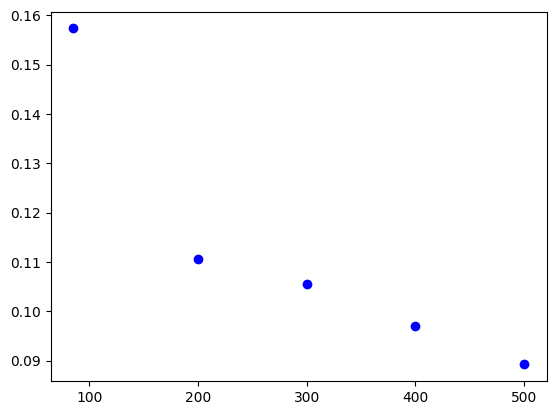

In [243]:
plt.scatter([85,200,300,400,500],[min(history1.history.get("mae")),min(history2.history.get("mae")),min(history3.history.get("mae")),
min(history4.history.get("mae")),min(history5.history.get("mae"))],c="blue")

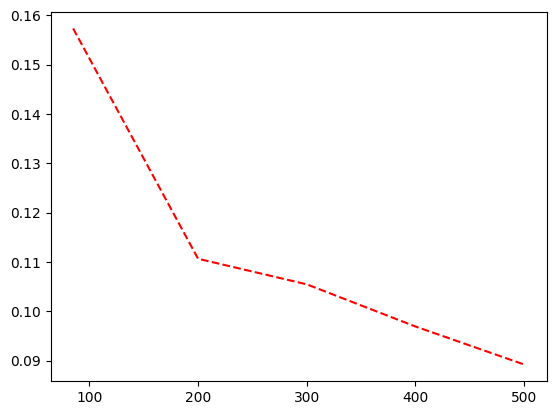

In [244]:
plt.plot([85,200,300,400,500],[min(history1.history.get("mae")),min(history2.history.get("mae")),min(history3.history.get("mae")),
min(history4.history.get("mae")),min(history5.history.get("mae"))],"r--")

***as you can see when i added more neurons on our modet , the mae went better***

## building 6 to 10 models

In [245]:
input_ = keras.layers.Input(shape = (16,))
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(input_)
output = keras.layers.Dense(1)(layer1)
model2 = keras.Model(input_,output)
model2.compile(loss = keras.losses.MeanAbsoluteError(),optimizer="Adam",metrics=["mae"])
history1 = model2.fit(xtrain , ytrain , validation_data=(xval,yval),epochs=100,
batch_size=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - loss: 1.3193 - mae: 1.3193 - val_loss: 1.3444 - val_mae: 1.3444
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 1.1792 - mae: 1.1792 - val_loss: 1.2428 - val_mae: 1.2428
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 1.0478 - mae: 1.0478 - val_loss: 1.1417 - val_mae: 1.1417
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.9261 - mae: 0.9261 - val_loss: 1.0467 - val_mae: 1.0467
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.8214 - mae: 0.8214 - val_loss: 0.9822 - val_mae: 0.9822
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.7560 - mae: 0.7560 - val_loss: 0.9252 - val_mae: 0.9252
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.7149 - mae: 0.7149 - val_loss: 0.8776 - val_mae: 0.8776
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.6919 - mae: 0.6919 - val_loss: 0.8445 - val_mae: 0.8445
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.6693 - mae:

In [246]:
input_ = keras.layers.Input(shape = (16,))
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(input_)
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(layer1)
output = keras.layers.Dense(1)(layer1)
model2 = keras.Model(input_,output)
model2.compile(loss = keras.losses.MeanAbsoluteError(),optimizer="Adam",metrics=["mae"])
history2 = model2.fit(xtrain , ytrain , validation_data=(xval,yval),epochs=100,
batch_size=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - loss: 1.4621 - mae: 1.4621 - val_loss: 0.9249 - val_mae: 0.9249
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 1.0012 - mae: 1.0012 - val_loss: 0.6451 - val_mae: 0.6451
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.6409 - mae: 0.6409 - val_loss: 0.5430 - val_mae: 0.5430
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.4928 - mae: 0.4928 - val_loss: 0.5131 - val_mae: 0.5131
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.5260 - mae: 0.5260 - val_loss: 0.5177 - val_mae: 0.5177
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.5497 - mae: 0.5497 - val_loss: 0.4870 - val_mae: 0.4870
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.4983 - mae: 0.4983 - val_loss: 0.3947 - val_mae: 0.3947
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.3681 - mae: 0.3681 - val_loss: 0.3375 - val_mae: 0.3375
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.3016 - mae:

In [247]:
input_ = keras.layers.Input(shape = (16,))
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(input_)
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(layer1)
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(layer1)
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(layer1)
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(layer1)
output = keras.layers.Dense(1)(layer1)
model2 = keras.Model(input_,output)
model2.compile(loss = keras.losses.MeanAbsoluteError(),optimizer="Adam",metrics=["mae"])
history3 = model2.fit(xtrain , ytrain , validation_data=(xval,yval),epochs=100,
batch_size=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 266ms/step - loss: 0.8568 - mae: 0.8568 - val_loss: 0.9131 - val_mae: 0.9131
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.9309 - mae: 0.9309 - val_loss: 0.6622 - val_mae: 0.6622
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.5605 - mae: 0.5605 - val_loss: 0.4791 - val_mae: 0.4791
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.4421 - mae: 0.4421 - val_loss: 0.5890 - val_mae: 0.5890
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.5388 - mae: 0.5388 - val_loss: 0.4354 - val_mae: 0.4354
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.3260 - mae: 0.3260 - val_loss: 0.4320 - val_mae: 0.4320
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.3391 - mae: 0.3391 - val_loss: 0.4987 - val_mae: 0.4987
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.3676 - mae: 0.3676 - val_loss: 0.4014 - val_mae: 0.4014
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.2385 - mae:

In [248]:
input_ = keras.layers.Input(shape = (16,))
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(input_)
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(layer1)
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(layer1)
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(layer1)
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(layer1)
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(layer1)
layer1 = keras.layers.Dense(100 , activation="relu",kernel_initializer=keras.initializers.he_normal())(layer1)
output = keras.layers.Dense(1)(layer1)
model2 = keras.Model(input_,output)
model2.compile(loss = keras.losses.MeanAbsoluteError(),optimizer="Adam",metrics=["mae"])
history4 = model2.fit(xtrain , ytrain , validation_data=(xval,yval),epochs=100,
batch_size=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 302ms/step - loss: 0.8640 - mae: 0.8640 - val_loss: 0.6430 - val_mae: 0.6430
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.5985 - mae: 0.5985 - val_loss: 0.6834 - val_mae: 0.6834
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.5435 - mae: 0.5435 - val_loss: 0.5163 - val_mae: 0.5163
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.3747 - mae: 0.3747 - val_loss: 0.4009 - val_mae: 0.4009
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.3687 - mae: 0.3687 - val_loss: 0.3534 - val_mae: 0.3534
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.2408 - mae: 0.2408 - val_loss: 0.4361 - val_mae: 0.4361
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.2703 - mae: 0.2703 - val_loss: 0.3995 - val_mae: 0.3995
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.2047 - mae: 0.2047 - val_loss: 0.3751 - val_mae: 0.3751
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.1959 - mae:

## ploting min(mae)

In [249]:
[min(history1.history.get("mae")),min(history2.history.get("mae")),min(history3.history.get("mae")),
min(history4.history.get("mae"))]

[0.1536046415567398,
 0.052343521267175674,
 0.048764605075120926,
 0.050317808985710144]

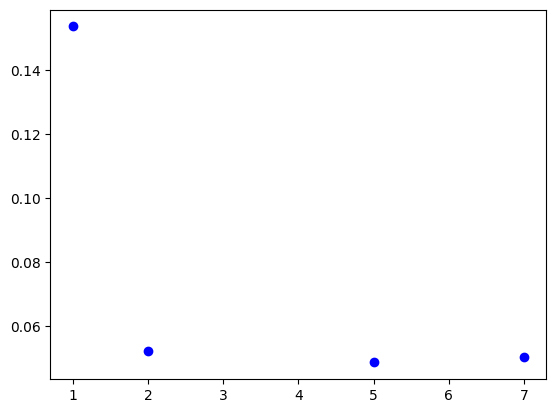

In [250]:
plt.scatter([1,2,5,7],[min(history1.history.get("mae")),min(history2.history.get("mae")),min(history3.history.get("mae")),
min(history4.history.get("mae"))],c = "blue")

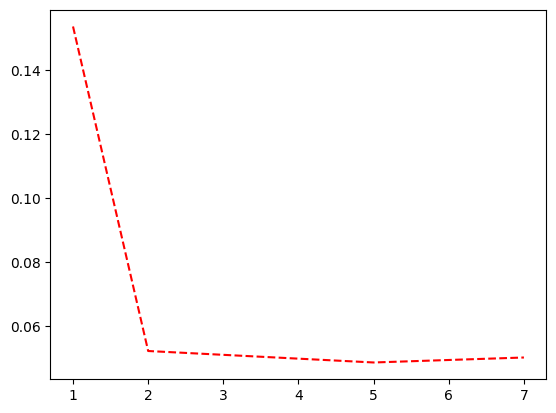

In [251]:
plt.plot([1,2,5,7],[min(history1.history.get("mae")),min(history2.history.get("mae")),min(history3.history.get("mae")),
min(history4.history.get("mae"))],"r--")

***as you can see when i added more leyer on our modet , the mae went better***

## building wide and deep model

In [252]:
input_ = keras.layers.Input(shape = (16,))
layer1 = keras.layers.Dense(70 , activation="relu",kernel_initializer=keras.initializers.he_normal())(input_)
normalize1 = keras.layers.BatchNormalization()(layer1)
layer2 = keras.layers.Dense(50,activation="relu",kernel_initializer=keras.initializers.he_normal())(normalize1)
normalize2 = keras.layers.BatchNormalization()(layer2)
layer2_5 = keras.layers.Dense(50,activation="relu",kernel_initializer=keras.initializers.he_normal())(normalize2)
normalize3 = keras.layers.BatchNormalization()(layer2_5)
layer3 = keras.layers.Dense(10,activation="relu",kernel_initializer=keras.initializers.he_normal())(normalize3)

concat = keras.layers.concatenate([input_,layer3])

output = keras.layers.Dense(1)(concat)
model3 = keras.Model(input_,output)

In [253]:
model3.compile(loss = keras.losses.MeanAbsoluteError(),optimizer="Adam",metrics=["mae"])
history1 = model3.fit(xtrain , ytrain , validation_data=(xval,yval),epochs=100,
batch_size=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 459ms/step - loss: 1.4156 - mae: 1.4156 - val_loss: 1.2453 - val_mae: 1.2453
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 1.1765 - mae: 1.1765 - val_loss: 1.1894 - val_mae: 1.1894
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.9896 - mae: 0.9896 - val_loss: 1.1395 - val_mae: 1.1395
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.7848 - mae: 0.7848 - val_loss: 1.1056 - val_mae: 1.1056
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.7026 - mae: 0.7026 - val_loss: 1.0645 - val_mae: 1.0645
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.6233 - mae: 0.6233 - val_loss: 1.0343 - val_mae: 1.0343
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.5691 - mae: 0.5691 - val_loss: 1.0074 - val_mae: 1.0074
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.5133 - mae: 0.5133 - val_loss: 0.9804 - val_mae: 0.9804
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.4873 -

In [254]:
history1.history.get("loss")

[1.4155720472335815,
 1.1765316724777222,
 0.9896271228790283,
 0.7847728729248047,
 0.7025730609893799,
 0.6232659816741943,
 0.5690776109695435,
 0.5133092999458313,
 0.4872635304927826,
 0.42427900433540344,
 0.38877561688423157,
 0.3861547112464905,
 0.3119557797908783,
 0.3114619553089142,
 0.28519171476364136,
 0.26195764541625977,
 0.23200905323028564,
 0.23782318830490112,
 0.2794820964336395,
 0.23350337147712708,
 0.2093915492296219,
 0.22352704405784607,
 0.1906191110610962,
 0.20157958567142487,
 0.1993657499551773,
 0.22383062541484833,
 0.20013491809368134,
 0.18739499151706696,
 0.1799059808254242,
 0.18849149346351624,
 0.17948701977729797,
 0.2442198544740677,
 0.1621202826499939,
 0.15751004219055176,
 0.19283826649188995,
 0.1543237715959549,
 0.15383478999137878,
 0.20920556783676147,
 0.17742450535297394,
 0.15620632469654083,
 0.13609178364276886,
 0.16393573582172394,
 0.14136865735054016,
 0.13525480031967163,
 0.1379716694355011,
 0.18612845242023468,
 0.139487

In [255]:
min(history1.history.get("mae")) , max(history1.history.get("mae"))


(0.09355426579713821, 1.4155720472335815)

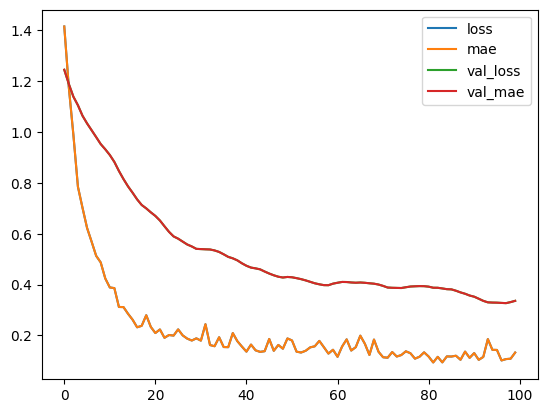

In [256]:
pd.DataFrame(history1.history).plot()
plt.show()

### evaluate Wide and deep NN

In [257]:
model3.evaluate(xtest,ytest)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.3722 - mae: 0.3722


[0.3722320795059204, 0.3722320795059204]

### evaluate DNN

In [258]:
model.evaluate(xtest,ytest)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.4239 - mean_absolute_error: 0.4239 - root_mean_squared_error: 0.5556


[0.4239231050014496, 0.4239231050014496, 0.5555860996246338]

***now we can see that Wide and deep model did better that normal deep model***

### Wide & DEEP VS DEEP  PLOT

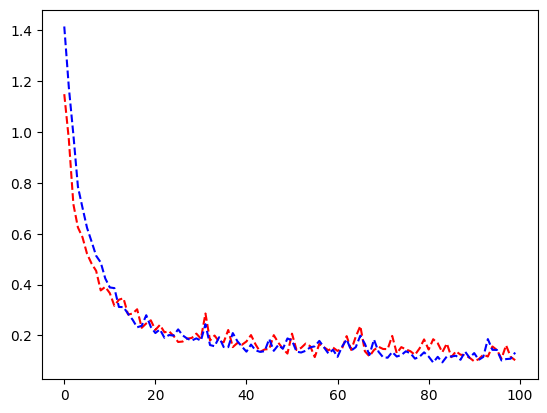

In [259]:
plt.plot(range(100),(history.history.get('loss')),"r--")
plt.plot(range(100),(history1.history.get('loss')),"b--")
plt.show()